## ${\textbf{Libraries}}$

In [1]:
import numpy as np
import pandas as pd
import scipy

#These are the visualization libraries. Matplotlib is standard and is what most people use.
#Seaborn works on top of matplotlib, as we mentioned in the course.
import matplotlib.pyplot as plt
import seaborn as sns
#sns.set()
#For standardizing features. We'll use the StandardScaler module.
from sklearn.preprocessing import StandardScaler
#Hierarchical clustering with the Sci Py library. We'll use the dendrogram and linkage modules.
from scipy.cluster.hierarchy import dendrogram, linkage
#Sk learn is one of the most widely used libraries for machine learning. We'll use the k means and pca modules.
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
# We need to save the models, which we'll use in the next section. We'll use pickle for that.
import pickle

## ${\textbf{Import Data}}$

In [2]:
# Load the data, contained in the segmentation data csv file.
df_customer_segmentation = pd.read_csv('customer_segmentation_data.csv', index_col = 0)

## ${\textbf{Explore Data}}$

In [3]:
# Descriptive analysis of the data set. Here we just look at the data to gain some insight. 
# We do not apply any transformations or changes to the data.
df_customer_segmentation.head()

,minutes_watched,CLV,region,channel
id,,,,
NaN,3197.0,205.42,2,4
NaN,63.0,149.99,0,1
NaN,605.0,119.00,2,2
NaN,20.0,240.00,2,4
NaN,245.0,184.36,1,4


In [4]:
df_customer_segmentation.describe()

,minutes_watched,CLV,region,channel
count,3725.000000,3834.000000,3834.000000,3834.000000
mean,1972.094497,118.383920,1.167188,3.870370
std,7401.693028,70.471274,0.923055,2.191972
min,0.000000,0.000000,0.000000,1.000000
25%,159.000000,62.580000,0.000000,2.000000
50%,512.000000,119.000000,2.000000,3.000000
75%,1521.000000,149.990000,2.000000,6.000000
max,288508.000000,626.400000,2.000000,8.000000


In [5]:
df_customer_segmentation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3834 entries, nan to nan
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minutes_watched  3725 non-null   float64
 1   CLV              3834 non-null   float64
 2   region           3834 non-null   int64  
 3   channel          3834 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 149.8 KB


In [6]:
print(np.isnan(df_customer_segmentation).any())

minutes_watched     True
CLV                False
region             False
channel            False
dtype: bool


In [7]:
df_customer_segmentation = df_customer_segmentation.dropna()

In [8]:
print(np.isnan(df_customer_segmentation).any())

minutes_watched    False
CLV                False
region             False
channel            False
dtype: bool


In [9]:
df_customer_segmentation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3725 entries, nan to nan
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minutes_watched  3725 non-null   float64
 1   CLV              3725 non-null   float64
 2   region           3725 non-null   int64  
 3   channel          3725 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 145.5 KB


## ${\textbf{Correlation Estimate}}$

In [10]:
# Compute Pearson correlation coefficient for the features in our data set.
# The correlation method in pandas, it has the Pearson correlation set as default.
df_customer_segmentation.corr()

,minutes_watched,CLV,region,channel
minutes_watched,1.000000,0.117021,0.039048,-0.002699
CLV,0.117021,1.000000,-0.272051,-0.026715
region,0.039048,-0.272051,1.000000,0.018412
channel,-0.002699,-0.026715,0.018412,1.000000


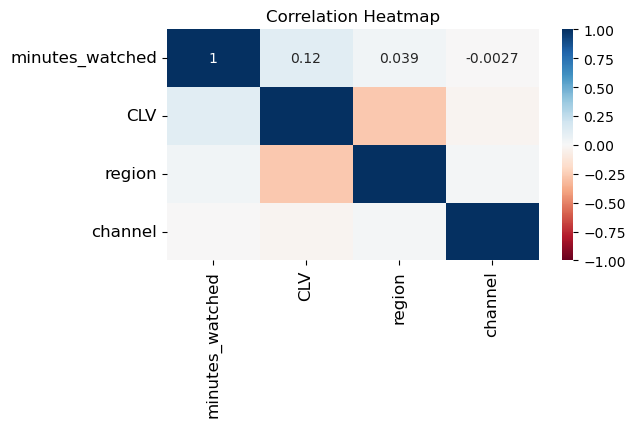

In [11]:
# We'll plot the correlations using a Heat Map. Heat Maps are a great way to visualize correlations using color coding.
# We use RdBu as a color scheme, but you can use viridis, Blues, YlGnBu or many others.
# We set the range from -1 to 1, as it is the range of the Pearson Correlation. 
# Otherwise the function infers the boundaries from the input.
# In this case they will be -0,25 to 0,68, as they are the minumum and maximum correlation indeces between our features.
plt.figure(figsize = (6,3))
s = sns.heatmap(df_customer_segmentation.corr(),
               annot = True, 
               cmap = 'RdBu',
               vmin = -1, 
               vmax = 1)
s.set_yticklabels(s.get_yticklabels(), rotation = 0, fontsize = 12)
s.set_xticklabels(s.get_xticklabels(), rotation = 90, fontsize = 12)
plt.title('Correlation Heatmap')
plt.show()

In [12]:
# the heatmap showing that there is negative correlation between the region and the channel that is meaning the most value persons
# who is in 'USA, Canada, United Kingdom, and Australia' and most important channels is 'Google, Facebook, YouTube, and LinkedIn'

## ${\textbf{Visualize Raw Data}}$

Text(0.5, 1.0, 'Visualization of raw data')

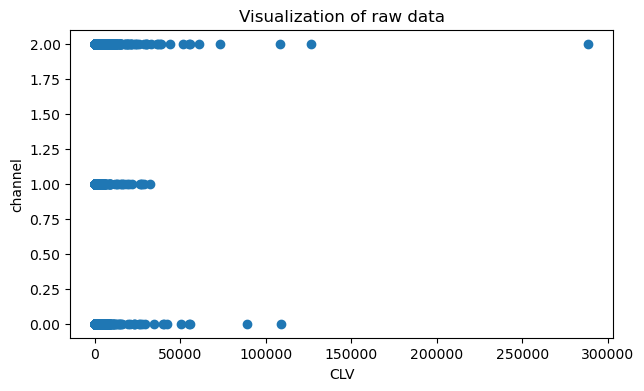

In [13]:
# We'll plot the data. We create a 12 by 9 inches figure.
# We have 2000 data points, which we'll scatter acrros Age and Income, located on positions 2 and 4 in our data set. 
plt.figure(figsize = (7, 4))
plt.scatter(df_customer_segmentation.iloc[:, 0], df_customer_segmentation.iloc[:, 2])
plt.xlabel('CLV')
plt.ylabel('channel')
plt.title('Visualization of raw data')

## ${\textbf{Standardization}}$

In [14]:
# Standardizing data, so that all features have equal weight. This is important for modelling.
# Otherwise, in our case Income would be considered much more important than Education for Instance. 
# We do not know if this is the case, so we would not like to introduce it to our model. 
# This is what is also refered to as bias.
scaler = StandardScaler()
customer_segmentation_std = scaler.fit_transform(df_customer_segmentation)

## ${\textbf{Hierarchical Clustering}}$

In [15]:
# Perform Hierarchical Clustering. The results are returned as a linkage matrix. 
hier_clust = linkage(customer_segmentation_std, method = 'ward')

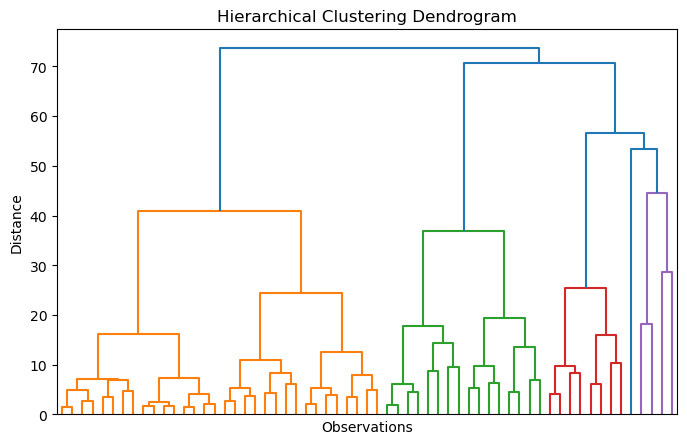

In [16]:
# We plot the results from the Hierarchical Clustering using a Dendrogram. 
# We truncate the dendrogram for better readability. The level p shows only the last p merged clusters
# We also omit showing the labels for each point.
plt.figure(figsize = (8,5))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')
dendrogram(hier_clust,
           truncate_mode = 'level', 
           p = 5, 
           show_leaf_counts = False, 
           no_labels = True
          )
plt.show()

In [17]:
# dendogram clustering the people into 4 groups that is depending on CLV between thr other columns

## ${\textbf{K-means Clustering}}$

In [18]:
# Perform K-means clustering. We consider 1 to 10 clusters, so our for loop runs 10 iterations.
# In addition we run the algortihm at many different starting points - k means plus plus. 
# And we set a random state for reproducibility.
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = 'auto' , random_state = 42)
    kmeans.fit(customer_segmentation_std)
    wcss.append(kmeans.inertia_)

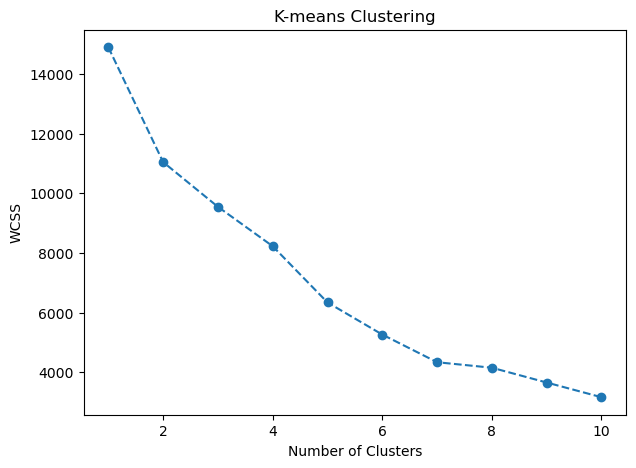

In [19]:
# Plot the Within Cluster Sum of Squares for the different number of clusters.
# From this plot we choose the number of clusters. 
# We look for a kink in the graphic, after which the descent of wcss isn't as pronounced.
plt.figure(figsize = (7,5))
plt.plot(range(1, 11), wcss, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means Clustering')
plt.show()

In [20]:
# We run K-means with a fixed number of clusters. In our case 4.
kmeans = KMeans(n_clusters = 4, init = 'k-means++', n_init = 'auto', random_state = 42)

In [21]:
# We divide our data into the four clusters.
kmeans.fit(customer_segmentation_std)

KMeans(n_clusters=4, n_init='auto', random_state=42)

### ${\textbf{Results}}$

In [22]:
# We create a new data frame with the original features and add a new column with the assigned clusters for each point.
df_cust_segm_kmeans = df_customer_segmentation.copy()
df_cust_segm_kmeans['Customer Segment K-means'] = kmeans.labels_

In [23]:
# Calculate mean values for the clusters
df_cust_segm_analysis = df_cust_segm_kmeans.groupby(['Customer Segment K-means']).mean()
df_cust_segm_analysis

,minutes_watched,CLV,region,channel
Customer Segment K-means,,,,
0,1492.009562,89.620624,1.958228,3.903875
1,1156.282557,147.209349,0.238351,3.807049
2,288508.000000,34.200000,2.000000,2.000000
3,34242.920635,236.140952,1.238095,4.000000


In [24]:
# Compute the size and proportions of the four clusters
df_cust_segm_analysis['N Obs'] = df_cust_segm_kmeans[['CLV','minutes_watched']].groupby(['CLV']).count()
df_cust_segm_analysis['Prop Obs'] = df_cust_segm_analysis['N Obs'] / df_cust_segm_analysis['N Obs'].sum()

In [25]:
df_cust_segm_analysis

,minutes_watched,CLV,region,channel,N Obs,Prop Obs
Customer Segment K-means,,,,,,
0,1492.009562,89.620624,1.958228,3.903875,10.0,0.833333
1,1156.282557,147.209349,0.238351,3.807049,2.0,0.166667
2,288508.000000,34.200000,2.000000,2.000000,NaN,NaN
3,34242.920635,236.140952,1.238095,4.000000,NaN,NaN


In [26]:
df_cust_segm_analysis.rename({0:'medium value',
                              1:'Above average value',
                              2:'lowest value',
                              3:'highest value'})

,minutes_watched,CLV,region,channel,N Obs,Prop Obs
Customer Segment K-means,,,,,,
medium value,1492.009562,89.620624,1.958228,3.903875,10.0,0.833333
Above average value,1156.282557,147.209349,0.238351,3.807049,2.0,0.166667
lowest value,288508.000000,34.200000,2.000000,2.000000,NaN,NaN
highest value,34242.920635,236.140952,1.238095,4.000000,NaN,NaN


In [ ]:
# we clustered these groups into 4 from the highest value to the lowest value, and most the students that consider highest value because
# high a lot minutes on channels but not as much the lowest value students, and most of them using channel 4 which are linkedin and it's
# profiable website for jops and bussines, and most of them from Western Europe which are strong fundementals counteries, On the contrary
# with lowest value students which having too much minutes on channels and most of them using They use entertainment channels that are less 
# profitable for the consumer, such as Facebook and most of them from the rest of the world which include most of them the weak fundementals
# counteries, the other 2 cluster are in between the highest and the lowest value students.

In [27]:
# Add the segment labels to our table
df_cust_segm_kmeans['Labels'] = df_cust_segm_kmeans['Customer Segment K-means'].map({0:'medium value',
                                                                                     1:'Above average value',
                                                                                     2:'lowest value',
                                                                                     3:'highest value'})

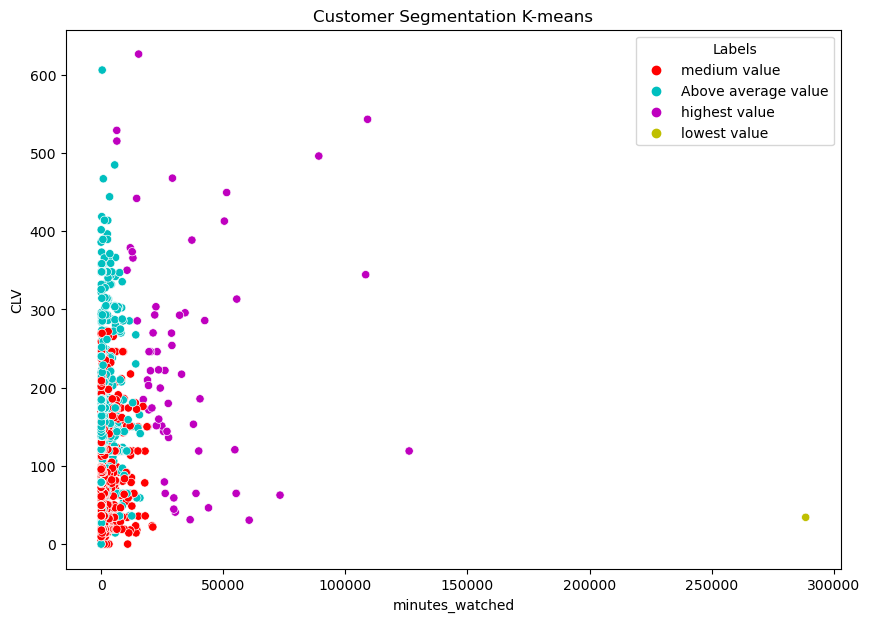

In [28]:
# We plot the results from the K-means algorithm. 
# Each point in our data set is plotted with the color of the clusters it has been assigned to.
x_axis = df_cust_segm_kmeans['minutes_watched']
y_axis = df_cust_segm_kmeans['CLV']
plt.figure(figsize = (10, 7))
sns.scatterplot(x=x_axis,y= y_axis, hue = df_cust_segm_kmeans['Labels'], palette = ['r', 'c', 'm', 'y'])
plt.title('Customer Segmentation K-means')
plt.show()

In [ ]:
# the following plot It expresses the four groupings of data, which is identical to the previous table for dividing the 
# social segments of those groupings, which was explained

### ${\textbf{PCA}}$

In [29]:
# Employ PCA to find a subset of components, which explain the variance in the data.
pca = PCA()

In [30]:
# Fit PCA with our standardized data.
pca.fit(customer_segmentation_std)

PCA()

In [31]:
# The attribute shows how much variance is explained by each of the seven individual components.
pca.explained_variance_ratio_

array([0.32180747, 0.25706429, 0.24909803, 0.17203021])

Text(0, 0.5, 'Cumulative Explained Variance')

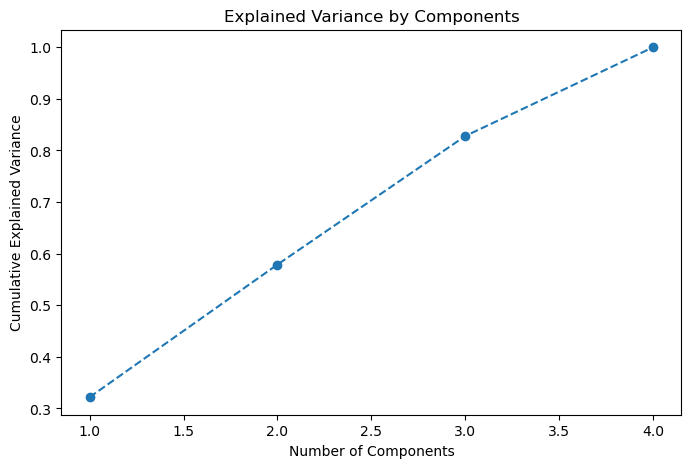

In [32]:
# Plot the cumulative variance explained by total number of components.
# On this graph we choose the subset of components we want to keep. 
# Generally, we want to keep around 80 % of the explained variance.
plt.figure(figsize = (8,5))
plt.plot(range(1,5), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [33]:
# We choose three components. 3 or 4 seems the right choice according to the previous graph.
pca = PCA(n_components = 3)

In [34]:
#Fit the model the our data with the selected number of components. In our case three.
pca.fit(customer_segmentation_std)

PCA(n_components=3)

### ${\textbf{PCA Results}}$

In [35]:
# Here we discucss the results from the PCA.
# The components attribute shows the loadings of each component on each of the seven original features.
# The loadings are the correlations between the components and the original features. 
pca.components_

array([[ 0.20347912,  0.71646363, -0.65803853, -0.11073126],
       [ 0.91814969,  0.09703016,  0.37827369,  0.06704709],
       [ 0.03317397, -0.06086775,  0.11081707, -0.99142029]])

In [36]:
df_pca_comp = pd.DataFrame(data = pca.components_,
                           columns = df_customer_segmentation.columns.values,
                           index = ['Component 1', 'Component 2', 'Component 3'])
df_pca_comp

,minutes_watched,CLV,region,channel
Component 1,0.203479,0.716464,-0.658039,-0.110731
Component 2,0.918150,0.097030,0.378274,0.067047
Component 3,0.033174,-0.060868,0.110817,-0.991420


([<matplotlib.axis.YTick at 0x169a131e9d0>,
 [Text(0, 0, 'Component 1'),
  Text(0, 1, 'Component 2'),
  Text(0, 2, 'Component 3')])

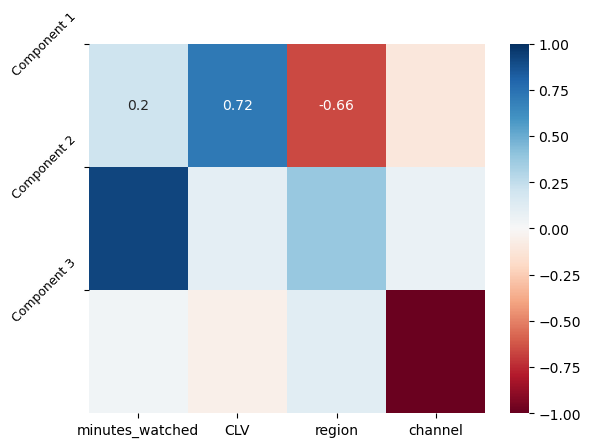

In [37]:
sns.heatmap(df_pca_comp,
            vmin = -1, 
            vmax = 1,
            cmap = 'RdBu',
            annot = True)
plt.yticks([0, 1, 2], 
           ['Component 1', 'Component 2', 'Component 3'],
           rotation = 45,
           fontsize = 9)

In [38]:
# the heatmap showing that the most that first component have strong positive correlation with CLV and waek positive correlation with 
# minutes_watched and strong negative correlation with the region and weak negative correlation with channel and the component has good
# explaintion for why the dataset clustered into 4 groups
 

In [39]:
pca.transform(customer_segmentation_std)

array([[ 0.32193986,  0.61543481, -0.03309991],
       [ 1.25403607, -0.76201768,  1.11931284],
       [-0.52314309,  0.11408097,  0.9357608 ],
       ...,
       [ 0.48367955, -0.83306527,  0.72715085],
       [-1.37860526, -0.06771942,  1.00470082],
       [-1.32835945, -0.09997218,  1.45771312]])

In [40]:
scores_pca = pca.transform(customer_segmentation_std)

### ${\textbf{K-means clustering with PCA}}$

In [41]:
# We fit K means using the transformed data from the PCA.
wcss = []
for i in range(1,11):
    kmeans_pca = KMeans(n_clusters = i, init = 'k-means++', n_init= 'auto', random_state = 42)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_)

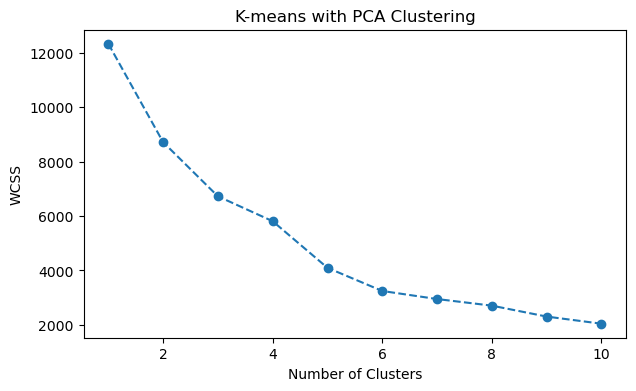

In [42]:
# Plot the Within Cluster Sum of Squares for the K-means PCA model. Here we make a decission about the number of clusters.
# Again it looks like four is the best option.
plt.figure(figsize = (7,4))
plt.plot(range(1, 11), wcss, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means with PCA Clustering')
plt.show()

In [43]:
# We have chosen four clusters, so we run K-means with number of clusters equals four. 
# Same initializer and random state as before.
kmeans_pca = KMeans(n_clusters = 4, init = 'k-means++', n_init= 'auto', random_state = 42)

In [44]:
# We fit our data with the k-means pca model
kmeans_pca.fit(scores_pca)

KMeans(n_clusters=4, n_init='auto', random_state=42)

### ${\textbf{K-means clustering with PCA Results}}$

In [45]:
# We create a new data frame with the original features and add the PCA scores and assigned clusters.
df_cust_segm_pca_kmeans = pd.concat([df_customer_segmentation.reset_index(drop = True), pd.DataFrame(scores_pca)], axis = 1)
df_cust_segm_pca_kmeans.columns.values[-3: ] = ['Component 1', 'Component 2', 'Component 3']
# The last column we add contains the pca k-means clustering labels.
df_cust_segm_pca_kmeans['Customer Segment K-means PCA'] = kmeans_pca.labels_

In [46]:
df_cust_segm_pca_kmeans

,minutes_watched,CLV,region,channel,Component 1,Component 2,Component 3,Customer Segment K-means PCA
0,3197.0,205.42,2,4,0.321940,0.615435,-0.033100,1
1,63.0,149.99,0,1,1.254036,-0.762018,1.119313,1
2,605.0,119.00,2,2,-0.523143,0.114081,0.935761,0
3,20.0,240.00,2,4,0.584720,0.268706,-0.077087,1
4,245.0,184.36,1,4,0.741387,-0.190032,-0.148432,1
...,...,...,...,...,...,...,...,...
3720,30.0,49.50,2,4,-1.343863,0.008723,0.086826,0
3721,11.0,79.00,0,3,0.432609,-0.804534,0.274004,1
3722,28.0,79.00,0,2,0.483680,-0.833065,0.727151,1
3723,57.0,36.00,2,2,-1.378605,-0.067719,1.004701,0


In [47]:
# We calculate the means by segments.
df_cust_segm_pca_kmeans_freq = df_cust_segm_pca_kmeans.groupby(['Customer Segment K-means PCA']).mean()
df_cust_segm_pca_kmeans_freq

,minutes_watched,CLV,region,channel,Component 1,Component 2,Component 3
Customer Segment K-means PCA,,,,,,,
0,2279.858806,85.735306,1.952693,2.679039,-0.814498,0.277647,0.658543
1,1685.265833,155.135778,0.309617,2.586396,1.049446,-0.378039,0.440630
2,1651.839442,81.584660,1.935428,6.788831,-1.069435,0.312880,-1.204803
3,2227.589178,153.203868,0.364729,7.024048,0.780894,-0.154821,-1.559222


In [48]:
# Calculate the size of each cluster and its proportion to the entire data set.
df_cust_segm_pca_kmeans_freq['N Obs'] = df_cust_segm_pca_kmeans[['Customer Segment K-means PCA','CLV']].groupby(['Customer Segment K-means PCA']).count()
df_cust_segm_pca_kmeans_freq['Prop Obs'] = df_cust_segm_pca_kmeans_freq['N Obs'] / df_cust_segm_pca_kmeans_freq['N Obs'].sum()
df_cust_segm_pca_kmeans_freq = df_cust_segm_pca_kmeans_freq.rename({0:'medium value',
                                                                    1:'Above average value',
                                                                    2:'lowest value',
                                                                    3:'highest value'})
df_cust_segm_pca_kmeans_freq

,minutes_watched,CLV,region,channel,Component 1,Component 2,Component 3,N Obs,Prop Obs
Customer Segment K-means PCA,,,,,,,,,
medium value,2279.858806,85.735306,1.952693,2.679039,-0.814498,0.277647,0.658543,1374,0.368859
Above average value,1685.265833,155.135778,0.309617,2.586396,1.049446,-0.378039,0.440630,1279,0.343356
lowest value,1651.839442,81.584660,1.935428,6.788831,-1.069435,0.312880,-1.204803,573,0.153826
highest value,2227.589178,153.203868,0.364729,7.024048,0.780894,-0.154821,-1.559222,499,0.133960


In [49]:
df_cust_segm_pca_kmeans_freq.describe()

,minutes_watched,CLV,region,channel,Component 1,Component 2,Component 3,N Obs,Prop Obs
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,1961.138315,118.914903,1.140617,4.769578,-0.013399,0.014417,-0.416213,931.250000,0.250000
std,338.797006,40.751759,0.928036,2.469592,1.082822,0.337161,1.128070,459.035492,0.123231
min,1651.839442,81.584660,0.309617,2.586396,-1.069435,-0.378039,-1.559222,499.000000,0.133960
25%,1676.909235,84.697644,0.350951,2.655878,-0.878232,-0.210625,-1.293408,554.500000,0.148859
50%,1956.427506,119.469587,1.150079,4.733935,-0.016802,0.061413,-0.382086,926.000000,0.248591
75%,2240.656585,153.686845,1.939744,6.847635,0.848032,0.286455,0.495108,1302.750000,0.349732
max,2279.858806,155.135778,1.952693,7.024048,1.049446,0.312880,0.658543,1374.000000,0.368859


In [50]:
df_cust_segm_pca_kmeans_freq.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, medium value to highest value
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minutes_watched  4 non-null      float64
 1   CLV              4 non-null      float64
 2   region           4 non-null      float64
 3   channel          4 non-null      float64
 4   Component 1      4 non-null      float64
 5   Component 2      4 non-null      float64
 6   Component 3      4 non-null      float64
 7   N Obs            4 non-null      int64  
 8   Prop Obs         4 non-null      float64
dtypes: float64(8), int64(1)
memory usage: 320.0+ bytes


In [51]:
df_cust_segm_pca_kmeans['Legend'] = df_cust_segm_pca_kmeans['Customer Segment K-means PCA'].map({0:'medium value',
                                                                                                 1:'Above average value',
                                                                                                 2:'lowest value',
                                                                                                 3:'highest value'})

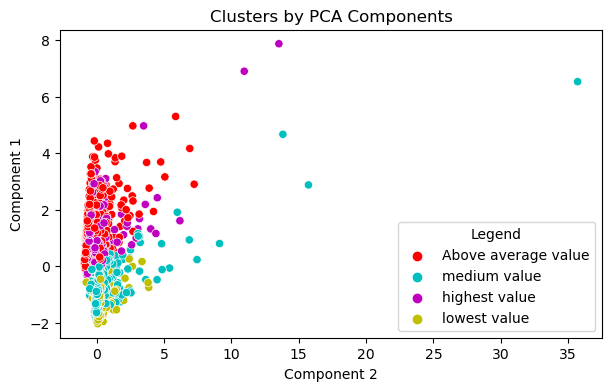

In [52]:
# Plot data by PCA components. The Y axis is the first component, X axis is the second.
x_axis = df_cust_segm_pca_kmeans['Component 2']
y_axis = df_cust_segm_pca_kmeans['Component 1']
plt.figure(figsize = (7, 4))
sns.scatterplot(x = x_axis, y = y_axis, hue = df_cust_segm_pca_kmeans['Legend'], palette = ['r', 'c', 'm', 'y'])
plt.title('Clusters by PCA Components')
plt.show()

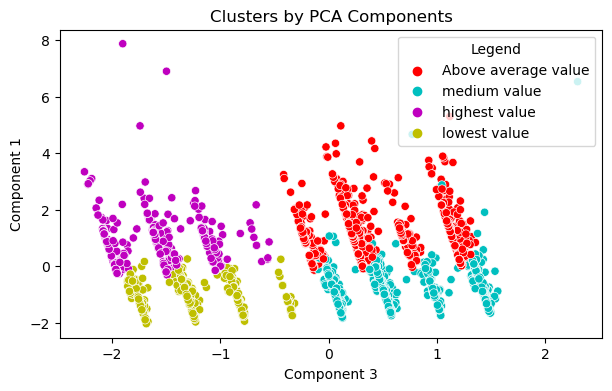

In [53]:
x_axis_1 = df_cust_segm_pca_kmeans['Component 3']
y_axis_1 = df_cust_segm_pca_kmeans['Component 1']
plt.figure(figsize = (7, 4))
sns.scatterplot(x = x_axis_1, y = y_axis_1, hue = df_cust_segm_pca_kmeans['Legend'], palette = ['r', 'c', 'm', 'y'])
plt.title('Clusters by PCA Components' )
plt.show()

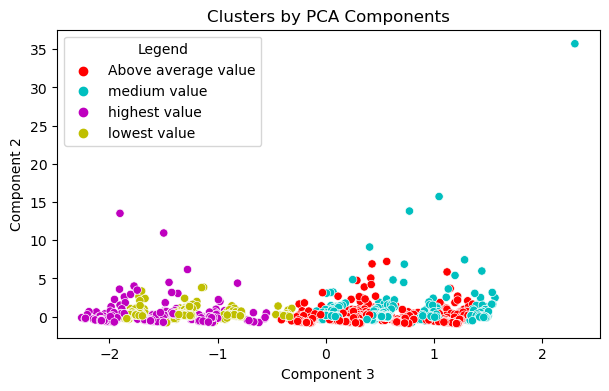

In [55]:
x_axis_1 = df_cust_segm_pca_kmeans['Component 3']
y_axis_1 = df_cust_segm_pca_kmeans['Component 2']
plt.figure(figsize = (7, 4))
sns.scatterplot(x = x_axis_1, y = y_axis_1, hue = df_cust_segm_pca_kmeans['Legend'], palette = ['r', 'c', 'm', 'y'])
plt.title('Clusters by PCA Components' )
plt.show()